 # Piano Note Classification from Audio

This project explores **frame-wise multi-label classification** of piano notes from audio using deep learning. I aim to transcribe polyphonic piano music into note activation matrices, using lightweight models trained on **CQT** and **Wav2Vec2** audio representations.

The workflow includes:
- Downloading and preprocessing the **MusicNet** dataset (focused on Bach pieces)
- Generating frame-aligned inputs and multi-hot labels
- Training various neural networks (**Transformer**, **GRU**, **CNN**) on two different input types
- Addressing class imbalance with threshold sweeping
- Visualising performance and evaluating models on a held-out test set

This notebook is structured for **full reproducibility**, from raw data to final evaluation. Each section includes brief explanations to help you understand the logic and results at each step. It is accompanied by three complementary notebooks in the project directory:

- `1_experiments_sweep.ipynb`: Runs hyperparameter sweeps and manages batch experiments across different configurations using the sweep.py script.
- `2_analysis_of_experiments.ipynb`: Aggregates and visualises the results of multiple trained models from the experiment sweeps.
- `3_investigations.ipynb`: Explores the effects of class imbalance in the dataset and evaluates the impact of various `pos_weight` techniques on model performance.

Note: The musicnet data folder and inputs folder will be missing from the directory until the Dataset Preparation and Preprocessing cells are executed below

Note: Ensure your current directory in this notebook is the project folder directory

**NB**
Due to the large file size (~1GB), model checkpoints are provided:
https://drive.google.com/file/d/1o4whn2uZ4ZdnjDXK9xUFE2xNZJzP5Qb3/view?usp=drive_link

This needs to be downloaded and named "checkpoints" in the project directory

## Project Directory Structure
```
FinalProject
│
├── checkpoints
│ ├── Early_Models
│ ├── Final
│ └── Experiments
│ ├── Parameter_Tuning
│ └── Pos_Weight_Test
│
├── data_processing
│ ├── bach_piece_splits.csv
│ ├── download_musicnet.py
│ ├── generate_bach_splits.py
│ ├── kaggle.json
│ └── preprocess_audio_multirep.py
│
├── figs
│ ├── CNN/
│ ├── GRU_(CQT)/
│ ├── GRU_(Wav2Vec)/
│ ├── Transformer_(CQT)/
│ └── Transformer_(Wav2Vec)/
│
├── inputs/
│
├── logs
│ ├── Data/
│ ├── Early_Models/
│ ├── Eval/
│ ├── Experiments/
│ └── Final/
│
├── models
│ ├── cnn.py
│ ├── gru.py
│ └── transformer.py
│
├── musicnet_dataset/
|
├── utils
│ ├── pycache/
│ ├── dataset.py
│ └── metrics.py
│
├── 0_README.ipynb
├── 1_experiments_sweep.ipynb
├── 2_analysis_of_experiments.ipynb
├── 3_investigations.ipynb
├── eval.py
├── experiment_hparams.yaml
├── hparams.yaml
├── main.py
├── requirements.txt
└── sweep.py

```

# 1. Setup and Dependencies



In [ ]:
! pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

## Download checkpointed Models from Drive

**NB**
Due to the large file size (~1GB), model checkpoints are provided here:

https://drive.google.com/file/d/1o4whn2uZ4ZdnjDXK9xUFE2xNZJzP5Qb3/view?usp=drive_link

This needs to be downloaded and named "checkpoints" in the project directory

In [ ]:
import matplotlib.pyplot as plt
import json
import os

from utils.metrics import threshold_sweep


## 2. Dataset Preparation and Preprocessing

The following cells handle downloading the MusicNet dataset (https://www.kaggle.com/datasets/imsparsh/musicnet-dataset).) , generating splits focused on Bach pieces, and preprocessing audio into multiple representations (CQT, Wav2Vec Mel).

- `download_musicnet.py` downloaded the dataset off Kaggle
- `generate_bach_splits.py` produces a `bach_piece_splits.csv` for reproducible Train/Val/Test partitioning.
- `preprocess_audio_multirep.py` creates:
  - CQT representations (used with input size 88)
  - Wav2Vec2 embeddings (used with input size 768)
  - Frame-aligned multi-hot label vectors


In [ ]:
# Download MusicNet Dataset

!python data_processing/download_musicnet.py


100% 21.5G/21.5G [16:54<00:00, 22.8MB/s]
Extracting files...
Dataset downloaded successfully to: /root/.cache/kagglehub/datasets/imsparsh/musicnet-dataset/versions/1
Dataset copied to: /content/drive/MyDrive/DeepLearning/FinalProject/musicnet_dataset


In [ ]:
! python data_processing/generate_bach_splits.py

Split file 'data_processing/bach_piece_splits.csv' already exists. Loading existing split.


In [ ]:
! python data_processing/preprocess_audio_multirep.py

2025-04-27 13:03:10.187742: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745758990.372786    1304 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745758990.422141    1304 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-27 13:03:10.836926: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
preprocessor_config.json: 100% 159/159 [00:00<00:00, 883kB/s]
tokenizer_config.json: 100% 163/163 [00:00<00:00, 874kB/s]
conf

# 3. Utility Functions for Plotting

This section defines functions to visualize:
- Training loss and validation F1 score over epochs
- Threshold vs. F1 curve (to analyse class imbalance and optimal thresholding)


In [ ]:



def plot_training_curves(log_path, model_name):
    with open(log_path) as f:
        log = json.load(f)

    # Create directory for plots
    save_dir = os.path.join("figs", model_name)
    os.makedirs(save_dir, exist_ok=True)

    epochs = list(range(1, len(log["train_losses"]) + 1))

    key_params = {
        "Best Val F1": round(log["best_val_f1"], 4),
        "Best Val Epoch": log["best_val_epoch"]
    }

    print("Training Configuration")
    for k, v in key_params.items():
        print(f"{k}: {v}")

    # Plot Training Loss
    plt.figure(figsize=(6,4))
    plt.plot(epochs, log["train_losses"], label='Training Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Training Loss Over Epochs")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_loss.png"))
    plt.show()
    plt.close()

    # Plot Validation Active F1
    plt.figure(figsize=(6,4))
    plt.plot(epochs, log["val_f1s"], label='Validation Active F1', color='green')
    plt.xlabel("Epoch")
    plt.ylabel("Active F1 Score")
    plt.title(f"{model_name} Validation Active F1 Over Epochs")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "validation_f1.png"))
    plt.show()
    plt.close()





def plot_threshold_vs_f1(results, model_name, best_threshold=None):
    """
    Plot Threshold vs Active F1 curve, optionally marking best threshold.
    """
    save_dir = os.path.join("figs", model_name)
    os.makedirs(save_dir, exist_ok=True)

    thresholds = [r["threshold"] for r in results]
    active_f1s = [r["active_f1"] for r in results]

    plt.figure(figsize=(6, 4))
    plt.plot(thresholds, active_f1s, marker='o')
    plt.xlabel("Threshold")
    plt.ylabel("Active F1 Score")
    plt.title("Threshold vs Active F1 on Validation Set")
    plt.grid(True)

    if best_threshold is not None:
        best_f1 = next(r["active_f1"] for r in results if abs(r["threshold"] - best_threshold) < 1e-6)
        plt.scatter(best_threshold, best_f1, color='red', s=100, marker='X', label=f"Best Threshold = {best_threshold:.2f}")
        plt.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7)
        plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "threshold_vs_f1.png"))
    plt.show()
    plt.close()



# 4. Training Models

Each training cell below launches a training run for a different model configuration.
- Supported architectures: Transformer, GRU, CNN
- Input representations: CQT or Wav2Vec2  or Mel for the CNN
- Training logs and checkpoints are saved for each model.


- **Reproducibility:** Random seeds fixed (2025) for Python, NumPy, and PyTorch. Train, Val and Test split is fixed. Results should be consistent across runs.

### Training: Transformer with CQT


In [ ]:
! python main.py Transformer_CQT


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
Using normal BCEWithLogitsLoss
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0020 | Recall: 0.0000
Epoch 1: Loss=0.3828, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 2: Loss=0.2086, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 3: Loss=0.1537, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 4: Loss=0.1349, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 5: Loss=0.1276, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 6: Loss=0.1241, Val Acti

Training Configuration
Best Val F1: 0.7269
Best Val Epoch: 154


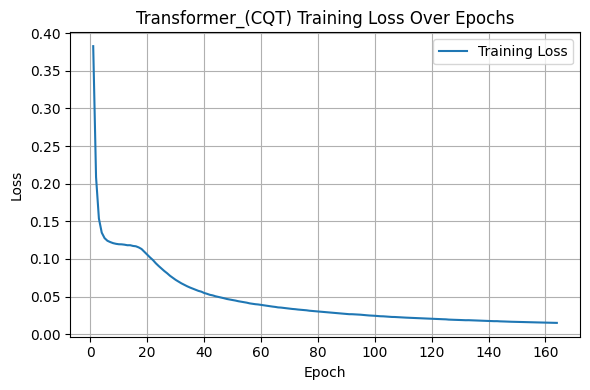

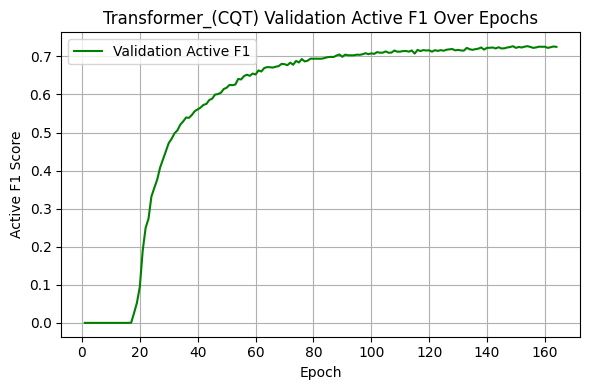

In [ ]:
plot_training_curves("logs/Final/Transformer_CQT/Transformer_CQT_280425_183201.json", "Transformer_(CQT)")

### Training: Transformer with Wav2Vec2


In [ ]:
! python main.py Transformer_Wav2Vec


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
Using normal BCEWithLogitsLoss
[Threshold = 0.30] Active F1: 0.0224 | Precision: 0.0168 | Recall: 0.1890
Epoch 1: Loss=0.4735, Val Active F1=0.0224
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 2: Loss=0.2962, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 3: Loss=0.2257, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 4: Loss=0.1813, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 5: Loss=0.1566, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 6: Loss=0.1436, Val Acti

Training Configuration
Best Val F1: 0.3977
Best Val Epoch: 202


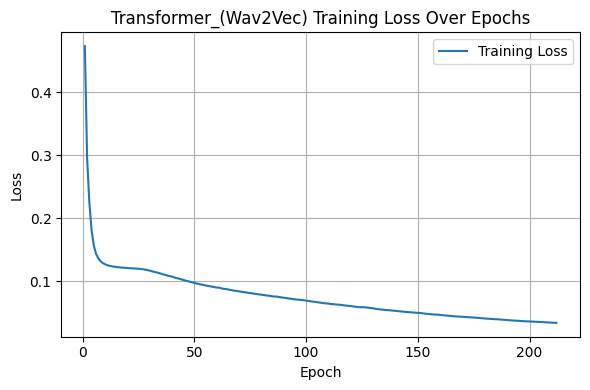

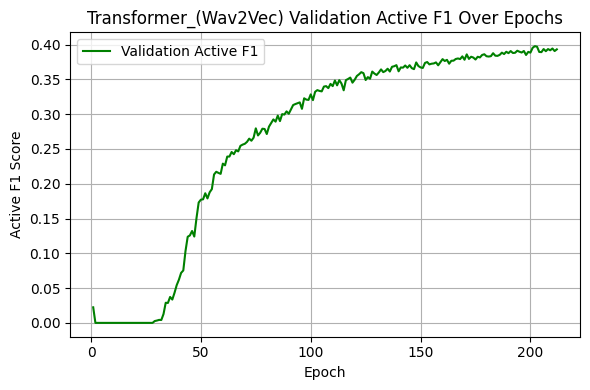

In [ ]:
plot_training_curves("logs/Final/Transformer_Wav2Vec/Transformer_Wav2Vec_280425_184601.json", "Transformer_(Wav2Vec)")

### Training: GRU with CQT


In [ ]:
! python main.py GRU_CQT


Using normal BCEWithLogitsLoss
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 1: Loss=0.4094, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 2: Loss=0.1412, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 3: Loss=0.1242, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 4: Loss=0.1207, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 5: Loss=0.1201, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 6: Loss=0.1194, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 7: Loss=0.1190, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 8: Loss=0.1189, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0

Training Configuration
Best Val F1: 0.6701
Best Val Epoch: 247


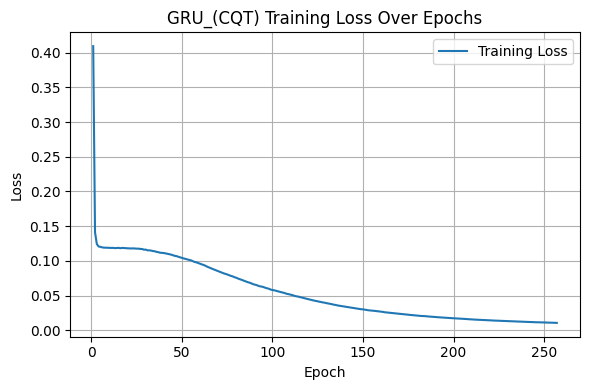

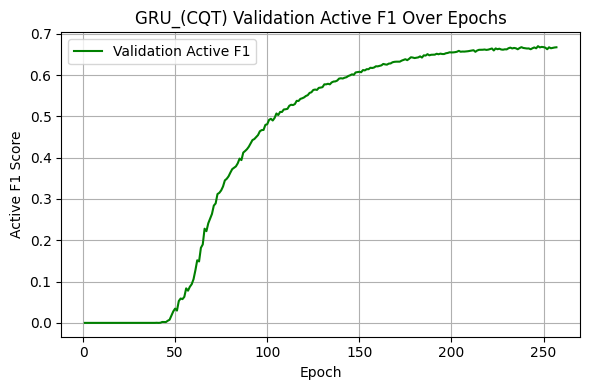

In [ ]:
plot_training_curves("logs/Final/GRU_CQT/GRU_CQT_280425_190050.json", "GRU_(CQT)")

### Training: GRU with Wav2Vec2


In [ ]:
! python main.py GRU_Wav2Vec

Using normal BCEWithLogitsLoss
[Threshold = 0.30] Active F1: 0.0077 | Precision: 0.0207 | Recall: 0.0334
Epoch 1: Loss=0.5006, Val Active F1=0.0077
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 2: Loss=0.2079, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 3: Loss=0.1436, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 4: Loss=0.1312, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 5: Loss=0.1269, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 6: Loss=0.1242, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 7: Loss=0.1226, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Epoch 8: Loss=0.1219, Val Active F1=0.0000
[Threshold = 0.30] Active F1: 0.0

Training Configuration
Best Val F1: 0.3585
Best Val Epoch: 371


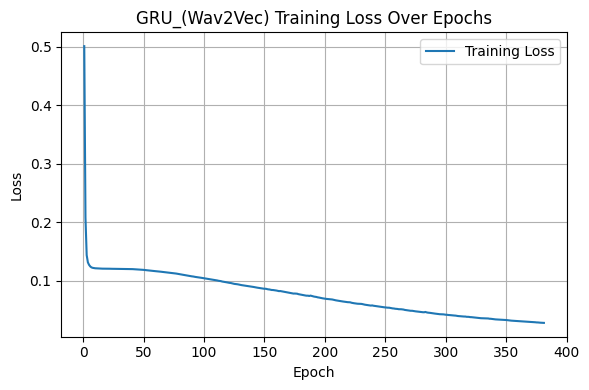

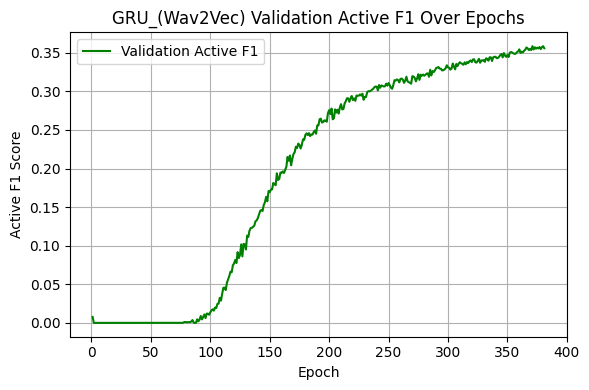

In [ ]:
plot_training_curves("logs/Final/GRU_Wav2Vec/GRU_Wav2Vec_280425_192118.json", "GRU_(Wav2Vec)")

### Training: CNN (Baseline, Mel Spectrogram)


In [ ]:
! python main.py CNN


Using normal BCEWithLogitsLoss
[Threshold = 0.30] Active F1: 0.2778 | Precision: 0.2016 | Recall: 0.5468
Epoch 1: Loss=0.5308, Val Active F1=0.2778
[Threshold = 0.30] Active F1: 0.4683 | Precision: 0.3451 | Recall: 0.7740
Epoch 2: Loss=0.3917, Val Active F1=0.4683
[Threshold = 0.30] Active F1: 0.4659 | Precision: 0.3509 | Recall: 0.7290
Epoch 3: Loss=0.3706, Val Active F1=0.4659
[Threshold = 0.30] Active F1: 0.4637 | Precision: 0.3629 | Recall: 0.6744
Epoch 4: Loss=0.3559, Val Active F1=0.4637
[Threshold = 0.30] Active F1: 0.4537 | Precision: 0.3816 | Recall: 0.6362
Epoch 5: Loss=0.3479, Val Active F1=0.4537
[Threshold = 0.30] Active F1: 0.4643 | Precision: 0.3922 | Recall: 0.6510
Epoch 6: Loss=0.3396, Val Active F1=0.4643
[Threshold = 0.30] Active F1: 0.4611 | Precision: 0.4102 | Recall: 0.6385
Epoch 7: Loss=0.3338, Val Active F1=0.4611
[Threshold = 0.30] Active F1: 0.4789 | Precision: 0.4074 | Recall: 0.6561
Epoch 8: Loss=0.3314, Val Active F1=0.4789
[Threshold = 0.30] Active F1: 0.4

Training Configuration
Best Val F1: 0.662
Best Val Epoch: 166


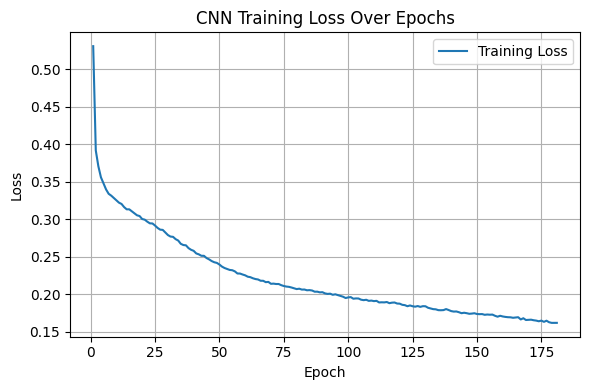

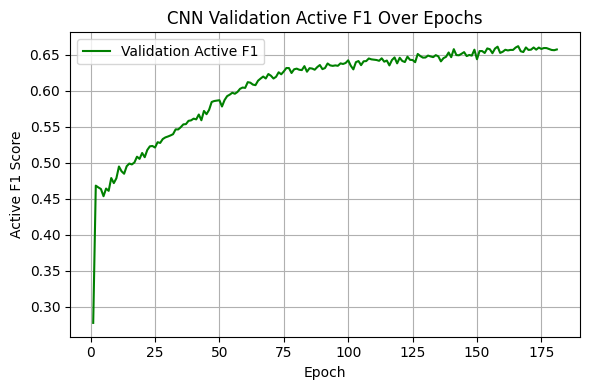

In [ ]:
plot_training_curves("logs/Final/CNN/CNN_280425_194458.json", "CNN")

## 5. Threshold Sweeps

For each trained model, I run a threshold sweep from 0.1 to 0.9 to find the optimal classification threshold for best F1 score. This is crucial due to the label imbalance.


### CQT Transformer

In [ ]:
results, best_threshold = threshold_sweep(
    model_key="Transformer_CQT",
    checkpoint_path="checkpoints/Final/Transformer_CQT_280425_183201/best.pth")

print(f"Best threshold: {best_threshold}")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[Threshold = 0.05] Active F1: 0.6726 | Precision: 0.5789 | Recall: 0.8179
[Threshold = 0.10] Active F1: 0.7072 | Precision: 0.6518 | Recall: 0.7818
[Threshold = 0.15] Active F1: 0.7207 | Precision: 0.6928 | Recall: 0.7580
[Threshold = 0.20] Active F1: 0.7265 | Precision: 0.7214 | Recall: 0.7389
[Threshold = 0.25] Active F1: 0.7280 | Precision: 0.7428 | Recall: 0.7216
[Threshold = 0.30] Active F1: 0.7269 | Precision: 0.7597 | Recall: 0.7055
[Threshold = 0.35] Active F1: 0.7237 | Precision: 0.7724 | Recall: 0.6902
[Threshold = 0.40] Active F1: 0.7201 | Precision: 0.7835 | Recall: 0.6764
[Threshold = 0.45] Active F1: 0.7143 | Precision: 0.7914 | Recall: 0.6615
[Threshold = 0.50] Active F1: 0.7087 | Precision: 0.8003 | Recall: 0.6472
[Threshold = 0.55] Active F1: 0.7023 | Precision: 0.8079 | Recall: 0.6328
[Threshold = 0.60] Active F1: 0.6951 | Precision: 0.8156 | Recall: 0.6175
[Threshold = 0.65] Active F1: 0.6865 | Precision: 0.8247 | Recall: 0.6005
[Threshold = 0.70] Active F1: 0.6773 |

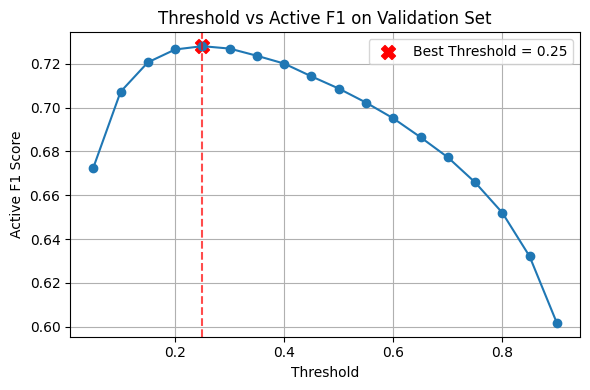

In [ ]:
plot_threshold_vs_f1(results,  "Transformer_(CQT)", best_threshold)

### Wav2Vec Transformer

In [ ]:
results, best_threshold = threshold_sweep(
    model_key="Transformer_Wav2Vec",
    checkpoint_path="checkpoints/Final/Transformer_Wav2Vec_280425_184601/best.pth"
)

print(f"Best threshold: {best_threshold}")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[Threshold = 0.05] Active F1: 0.3581 | Precision: 0.2679 | Recall: 0.5944
[Threshold = 0.10] Active F1: 0.3876 | Precision: 0.3295 | Recall: 0.5203
[Threshold = 0.15] Active F1: 0.3988 | Precision: 0.3745 | Recall: 0.4759
[Threshold = 0.20] Active F1: 0.4014 | Precision: 0.4078 | Recall: 0.4416
[Threshold = 0.25] Active F1: 0.4014 | Precision: 0.4367 | Recall: 0.4142
[Threshold = 0.30] Active F1: 0.3977 | Precision: 0.4643 | Recall: 0.3898
[Threshold = 0.35] Active F1: 0.3925 | Precision: 0.4871 | Recall: 0.3682
[Threshold = 0.40] Active F1: 0.3858 | Precision: 0.5022 | Recall: 0.3479
[Threshold = 0.45] Active F1: 0.3781 | Precision: 0.5123 | Recall: 0.3294
[Threshold = 0.50] Active F1: 0.3702 | Precision: 0.5050 | Recall: 0.3118
[Threshold = 0.55] Active F1: 0.3616 | Precision: 0.5206 | Recall: 0.2946
[Threshold = 0.60] Active F1: 0.3524 | Precision: 0.5394 | Recall: 0.2781
[Threshold = 0.65] Active F1: 0.3410 | Precision: 0.5542 | Recall: 0.2611
[Threshold = 0.70] Active F1: 0.3278 |

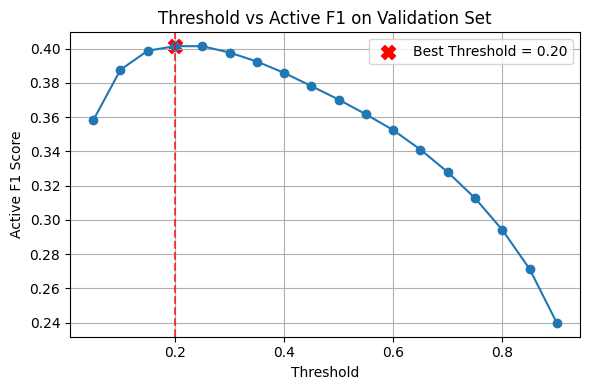

In [ ]:
plot_threshold_vs_f1(results, "Transformer_(Wav2Vec)", best_threshold)

### CQT GRU

In [ ]:
results, best_threshold = threshold_sweep(
    model_key="GRU_CQT",
    checkpoint_path="checkpoints/Final/GRU_CQT_280425_190050/best.pth")

print(f"Best threshold: {best_threshold}")

[Threshold = 0.05] Active F1: 0.6021 | Precision: 0.5015 | Recall: 0.7839
[Threshold = 0.10] Active F1: 0.6420 | Precision: 0.5797 | Recall: 0.7378
[Threshold = 0.15] Active F1: 0.6574 | Precision: 0.6248 | Recall: 0.7077
[Threshold = 0.20] Active F1: 0.6653 | Precision: 0.6578 | Recall: 0.6858
[Threshold = 0.25] Active F1: 0.6690 | Precision: 0.6851 | Recall: 0.6667
[Threshold = 0.30] Active F1: 0.6701 | Precision: 0.7087 | Recall: 0.6503
[Threshold = 0.35] Active F1: 0.6665 | Precision: 0.7246 | Recall: 0.6331
[Threshold = 0.40] Active F1: 0.6633 | Precision: 0.7417 | Recall: 0.6180
[Threshold = 0.45] Active F1: 0.6584 | Precision: 0.7571 | Recall: 0.6029
[Threshold = 0.50] Active F1: 0.6538 | Precision: 0.7708 | Recall: 0.5893
[Threshold = 0.55] Active F1: 0.6487 | Precision: 0.7835 | Recall: 0.5757
[Threshold = 0.60] Active F1: 0.6424 | Precision: 0.7980 | Recall: 0.5615
[Threshold = 0.65] Active F1: 0.6343 | Precision: 0.8105 | Recall: 0.5455
[Threshold = 0.70] Active F1: 0.6248 |

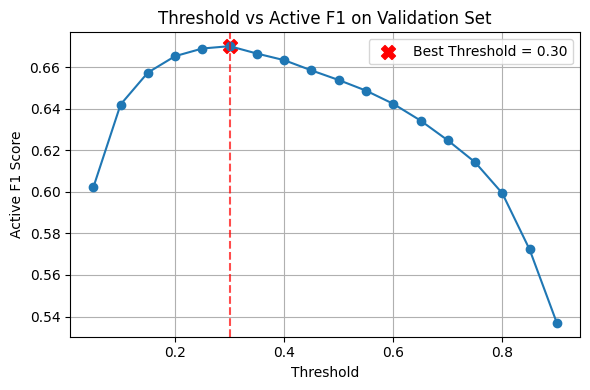

In [ ]:
plot_threshold_vs_f1(results, "GRU_(CQT)", best_threshold)


## Wav2Vec GRU

In [ ]:
results, best_threshold = threshold_sweep(
    model_key="GRU_Wav2Vec",
    checkpoint_path="checkpoints/Final/GRU_Wav2Vec_280425_192118/best.pth" # update
)

print(f"Best threshold: {best_threshold}")

[Threshold = 0.05] Active F1: 0.3154 | Precision: 0.2287 | Recall: 0.5721
[Threshold = 0.10] Active F1: 0.3437 | Precision: 0.2836 | Recall: 0.4997
[Threshold = 0.15] Active F1: 0.3527 | Precision: 0.3100 | Recall: 0.4534
[Threshold = 0.20] Active F1: 0.3595 | Precision: 0.3386 | Recall: 0.4221
[Threshold = 0.25] Active F1: 0.3614 | Precision: 0.3683 | Recall: 0.3951
[Threshold = 0.30] Active F1: 0.3585 | Precision: 0.3693 | Recall: 0.3703
[Threshold = 0.35] Active F1: 0.3526 | Precision: 0.3844 | Recall: 0.3470
[Threshold = 0.40] Active F1: 0.3473 | Precision: 0.4001 | Recall: 0.3262
[Threshold = 0.45] Active F1: 0.3397 | Precision: 0.4131 | Recall: 0.3063
[Threshold = 0.50] Active F1: 0.3323 | Precision: 0.4329 | Recall: 0.2883
[Threshold = 0.55] Active F1: 0.3240 | Precision: 0.4568 | Recall: 0.2710
[Threshold = 0.60] Active F1: 0.3136 | Precision: 0.4613 | Recall: 0.2533
[Threshold = 0.65] Active F1: 0.3039 | Precision: 0.4633 | Recall: 0.2372
[Threshold = 0.70] Active F1: 0.2925 |

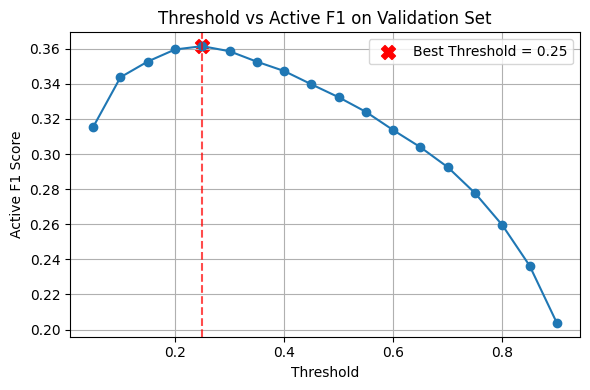

In [ ]:
plot_threshold_vs_f1(results, "GRU_(Wav2Vec)", best_threshold)


### CNN

In [ ]:
results, best_threshold = threshold_sweep(
    model_key="CNN",
    checkpoint_path="checkpoints/Final/CNN_280425_194458/best.pth" #
)

print(f"Best threshold: {best_threshold}")


[Threshold = 0.05] Active F1: 0.5839 | Precision: 0.4352 | Recall: 0.9576
[Threshold = 0.10] Active F1: 0.6188 | Precision: 0.4840 | Recall: 0.8959
[Threshold = 0.15] Active F1: 0.6334 | Precision: 0.5316 | Recall: 0.8439
[Threshold = 0.20] Active F1: 0.6426 | Precision: 0.5441 | Recall: 0.8019
[Threshold = 0.25] Active F1: 0.6578 | Precision: 0.5839 | Recall: 0.7705
[Threshold = 0.30] Active F1: 0.6620 | Precision: 0.6142 | Recall: 0.7338
[Threshold = 0.35] Active F1: 0.6587 | Precision: 0.6385 | Recall: 0.6991
[Threshold = 0.40] Active F1: 0.6537 | Precision: 0.6613 | Recall: 0.6662
[Threshold = 0.45] Active F1: 0.6426 | Precision: 0.6861 | Recall: 0.6294
[Threshold = 0.50] Active F1: 0.6267 | Precision: 0.7074 | Recall: 0.5900
[Threshold = 0.55] Active F1: 0.6133 | Precision: 0.7461 | Recall: 0.5558
[Threshold = 0.60] Active F1: 0.5968 | Precision: 0.7743 | Recall: 0.5196
[Threshold = 0.65] Active F1: 0.5732 | Precision: 0.7957 | Recall: 0.4811
[Threshold = 0.70] Active F1: 0.5325 |

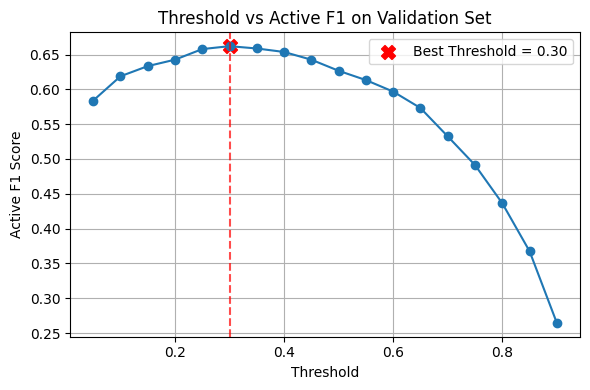

In [ ]:
plot_threshold_vs_f1(results, "CNN", best_threshold)

# 7. Final Model Evaluation

Evaluates each trained model on the test set using the best threshold identified in the sweep. Outputs include precision, recall, and F1 metrics.


In [ ]:
! python eval.py Transformer_CQT --checkpoint checkpoints/Final/Transformer_CQT_280425_183201/best.pth --threshold 0.25

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(

Evaluating model Transformer_CQT (loaded from checkpoints/Final/Transformer_CQT_280425_183201/best.pth) on test set at threshold 0.25

 Test Evaluation:
Threshold 0.25 | Active F1: 0.6829 | Precision: 0.7187 | Recall: 0.6673

Saved test evaluation result to logs/Eval/Transformer_CQT_best_test_eval.json


In [ ]:
! python eval.py Transformer_Wav2Vec --checkpoint checkpoints/Final/Transformer_Wav2Vec_280425_184601/best.pth --threshold 0.2

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(

Evaluating model Transformer_Wav2Vec (loaded from checkpoints/Final/Transformer_Wav2Vec_280425_184601/best.pth) on test set at threshold 0.20

 Test Evaluation:
Threshold 0.20 | Active F1: 0.3095 | Precision: 0.3378 | Recall: 0.3382

Saved test evaluation result to logs/Eval/Transformer_Wav2Vec_best_test_eval.json


In [ ]:
! python eval.py GRU_CQT --checkpoint checkpoints/Final/GRU_CQT_280425_190050/best.pth --threshold 0.3



Evaluating model GRU_CQT (loaded from checkpoints/Final/GRU_CQT_280425_190050/best.pth) on test set at threshold 0.30

 Test Evaluation:
Threshold 0.30 | Active F1: 0.6334 | Precision: 0.6619 | Recall: 0.6190

Saved test evaluation result to logs/Eval/GRU_CQT_best_test_eval.json


In [ ]:
! python eval.py GRU_Wav2Vec --checkpoint checkpoints/Final/GRU_Wav2Vec_280425_192118/best.pth --threshold 0.25


Evaluating model GRU_Wav2Vec (loaded from checkpoints/Final/GRU_Wav2Vec_280425_192118/best.pth) on test set at threshold 0.25

 Test Evaluation:
Threshold 0.25 | Active F1: 0.2862 | Precision: 0.2952 | Recall: 0.3129

Saved test evaluation result to logs/Eval/GRU_Wav2Vec_best_test_eval.json


In [ ]:
! python eval.py CNN --checkpoint checkpoints/Final/CNN_280425_194458/best.pth --threshold 0.3


Evaluating model CNN (loaded from checkpoints/Final/CNN_280425_194458/best.pth) on test set at threshold 0.30

 Test Evaluation:
Threshold 0.30 | Active F1: 0.6282 | Precision: 0.6135 | Recall: 0.7015

Saved test evaluation result to logs/Eval/CNN_best_test_eval.json


### Final note-wise evalution for best performing model

In [ ]:
! python eval.py Transformer_CQT --checkpoint checkpoints/Final/Transformer_CQT_280425_183201/best.pth --threshold 0.25 --plot_notewise_f1

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(

Evaluating model Transformer_CQT (loaded from checkpoints/Final/Transformer_CQT_280425_183201/best.pth) on test set at threshold 0.25

 Test Evaluation:
Threshold 0.25 | Active F1: 0.6829 | Precision: 0.7187 | Recall: 0.6673

Saved test evaluation result to logs/Eval/Transformer_CQT_best_test_eval.json
Saved note-wise F1 score plot to logs/Eval/Transformer_CQT_best_f1_per_note.png
Figure(2000x600)


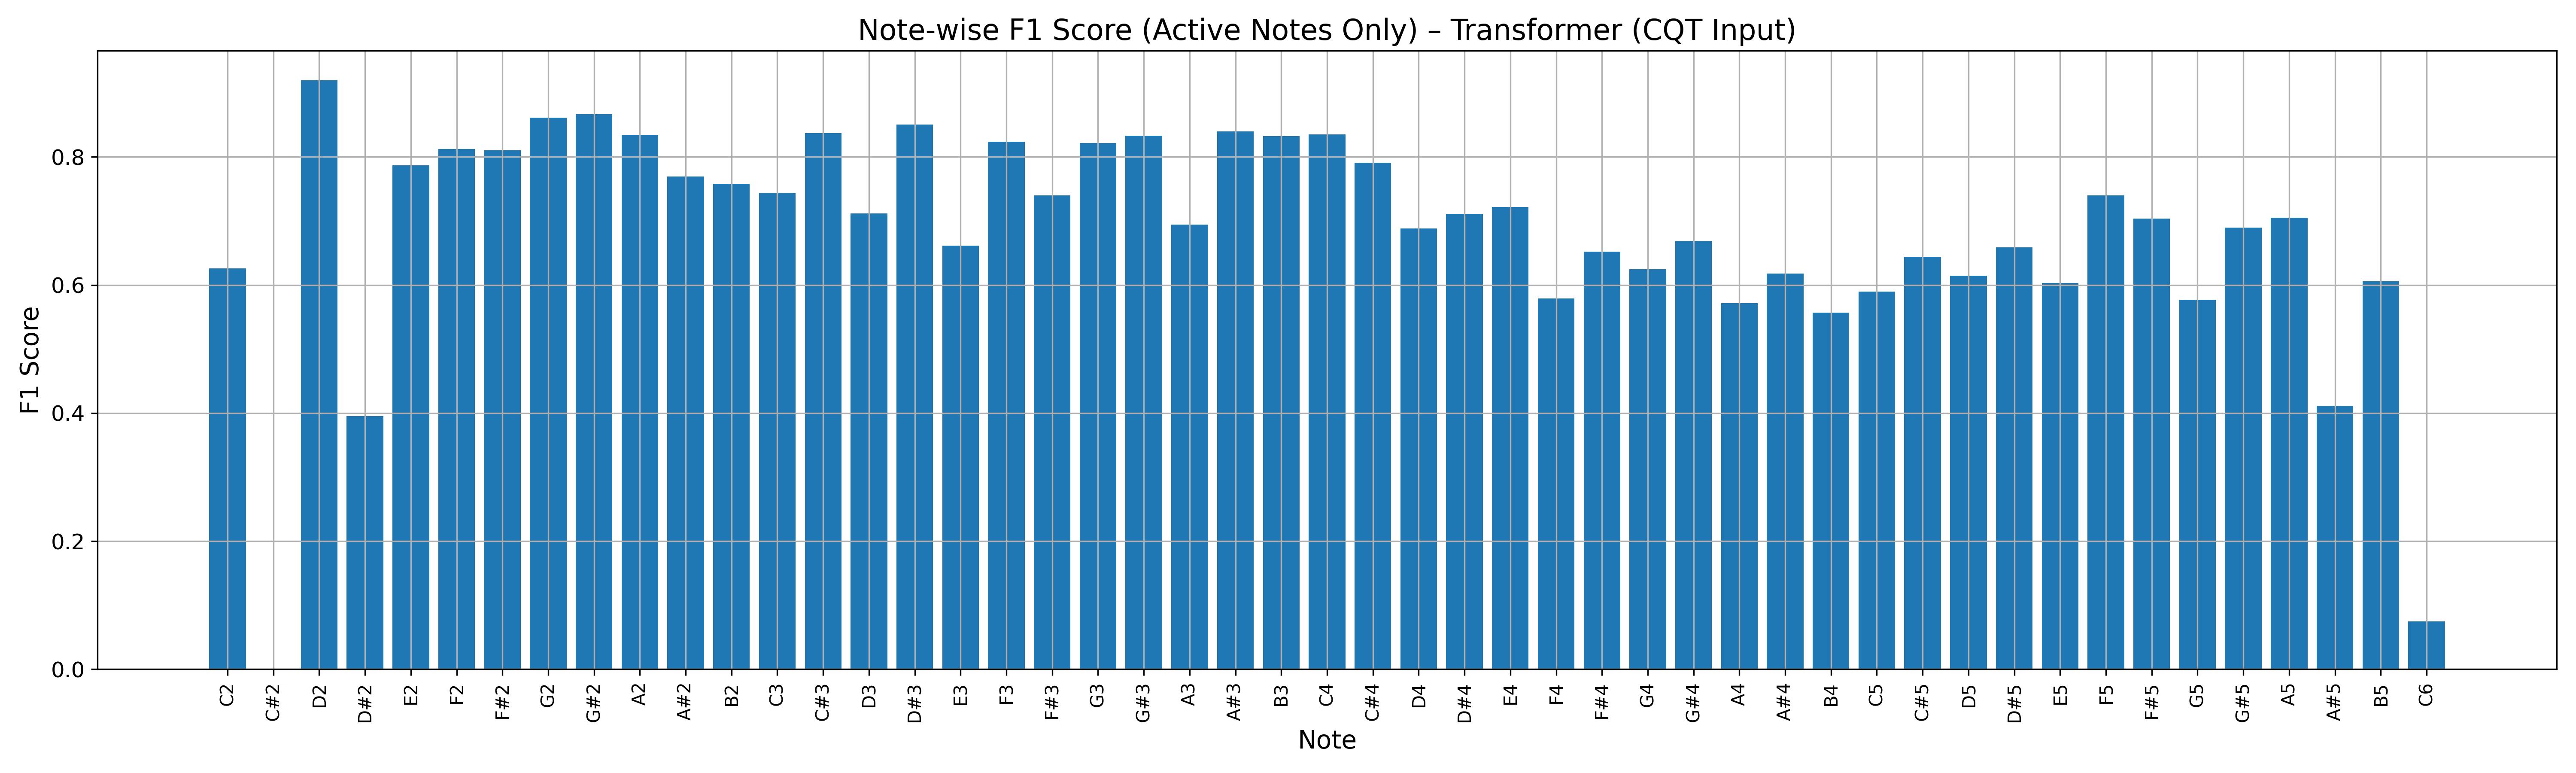